In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [4]:
img = cv2.imread('images/dog.jpg')

In [5]:
q_width, q_height = img.shape[1] // 4, img.shape[0] // 4
q_width, q_height

(100, 100)

In [6]:
# define affine translation matrix

T = np.float32([[1,0,q_width],[0,1,q_height]])
T

array([[  1.,   0., 100.],
       [  0.,   1., 100.]], dtype=float32)

In [7]:
trans_img = cv2.warpAffine(img, T, (img.shape[1], img.shape[0]))

In [8]:
cv2.imshow('Translated Image', trans_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [9]:
trans_img = cv2.warpAffine(img, T, (600,600)) # fixed above problem of lossing pixels

In [10]:
cv2.imshow('Translated Image', trans_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [11]:
help(cv2.warpAffine)

Help on built-in function warpAffine:

warpAffine(...)
    warpAffine(src, M, dsize[, dst[, flags[, borderMode[, borderValue]]]]) -> dst
    .   @brief Applies an affine transformation to an image.
    .   
    .   The function warpAffine transforms the source image using the specified matrix:
    .   
    .   \f[\texttt{dst} (x,y) =  \texttt{src} ( \texttt{M} _{11} x +  \texttt{M} _{12} y +  \texttt{M} _{13}, \texttt{M} _{21} x +  \texttt{M} _{22} y +  \texttt{M} _{23})\f]
    .   
    .   when the flag #WARP_INVERSE_MAP is set. Otherwise, the transformation is first inverted
    .   with #invertAffineTransform and then put in the formula above instead of M. The function cannot
    .   operate in-place.
    .   
    .   @param src input image.
    .   @param dst output image that has the size dsize and the same type as src .
    .   @param M \f$2\times 3\f$ transformation matrix.
    .   @param dsize size of the output image.
    .   @param flags combination of interpolation methods (

In [12]:
# Border color - white
trans_img = cv2.warpAffine(img, T, (600,600), borderValue = [255, 255, 255])
cv2.imshow('Translated Image', trans_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

#### define translation matrix

In [13]:
T = np.float32([[1,0,50],[0,1,-50]])  #negative value perform opposite operation

In [14]:
trans_img = cv2.warpAffine(img, T, (400,400))
cv2.imshow('Translated Image', trans_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

#### Image Rotation

In [15]:
# Turning an image around a fixed point
img_90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
img_90a = cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
img_180 = cv2.rotate(img, cv2.ROTATE_180)

In [16]:
cv2.imshow('90 Clockwise', img_90)
cv2.imshow('90 Anti-Clockwise', img_90a)
cv2.imshow('180 Degrees', img_180)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [18]:
center = img.shape[1] // 2, img.shape[0] // 2 
center

(200, 200)

In [21]:
angle = 30
R =cv2.getRotationMatrix2D(center, angle, 1.0)
R

array([[  0.8660254 ,   0.5       , -73.20508076],
       [ -0.5       ,   0.8660254 , 126.79491924]])

In [22]:
img_rot = cv2.warpAffine(img, R, (400,400))
cv2.imshow('Rotated Image', img_rot)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [24]:
angle = -65
R =cv2.getRotationMatrix2D((300,300), angle, 1.0)

img_rot = cv2.warpAffine(img, R, (600,600))
cv2.imshow('Rotated Image', img_rot)
cv2.waitKey(0)
cv2.destroyAllWindows()

#### Image Resizing 

In [26]:
img_res = cv2.resize(img, (600,600))
img_res.shape

(600, 600, 3)

In [27]:
cv2.imshow('Resized Image', img_res)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [28]:
img_res = cv2.resize(img, (700,550))
cv2.imshow('Resized Image', img_res)
cv2.waitKey(0)
cv2.destroyAllWindows()

#### Image Scaling  

In [29]:
img_res = cv2.resize(img, None, fx=1.5, fy=1.5)
print('size: ',img_res.shape)
cv2.imshow('Resized Image', img_res)
cv2.waitKey(0)
cv2.destroyAllWindows()

size:  (600, 602, 3)


In [30]:
from skimage.transform import resize

In [31]:
img_rgb = plt.imread('images/dog.jpg')

In [32]:
img_res = resize(img_rgb, (1000,1000))
img_res.shape

(1000, 1000, 3)

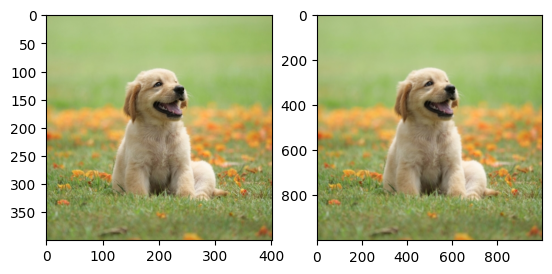

In [34]:
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.subplot(1,2,2)
plt.imshow(img_res)

In [35]:
from PIL import Image

In [39]:
img_pil = Image.open('images/dog.jpg')

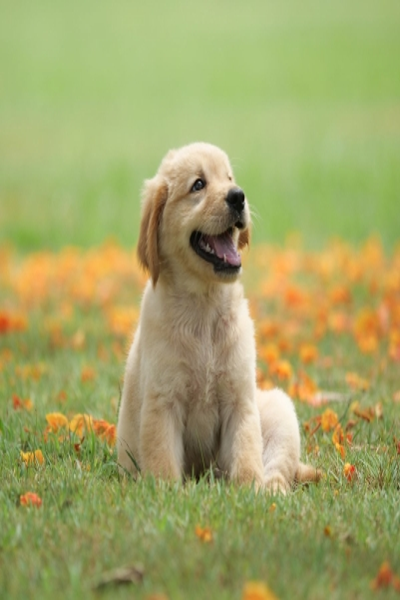

In [40]:
img_pil.resize((400,600))

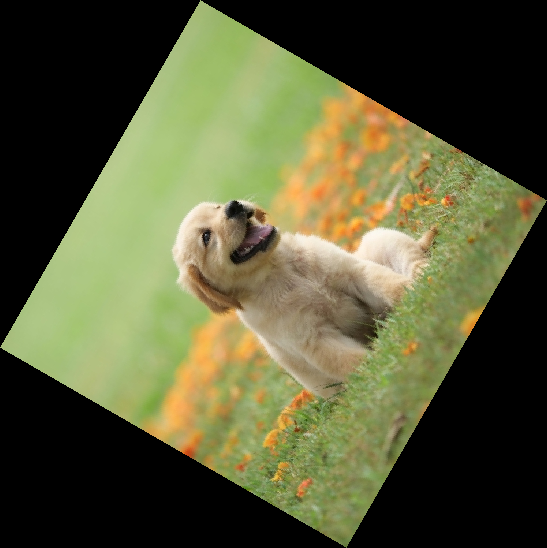

In [44]:
img_pil.rotate(60, expand=True)

#### Image Flipping

In [46]:
img_new = np.flip(img_rgb)

cv2.imshow('Flipped Image', img_new)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [47]:
img_new = np.flip(img_rgb, axis=1)

cv2.imshow('Flipped Image', img_new)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [48]:
## Flip function from CV

# Horizontal Flip
img_hor = cv2.flip(img_rgb, 0)
# Vertical Flip
img_ver = cv2.flip(img_rgb, 1)
# Diagonal Flip
img_dia = cv2.flip(img_rgb, -1)

Text(0.5, 1.0, 'Diagonal')

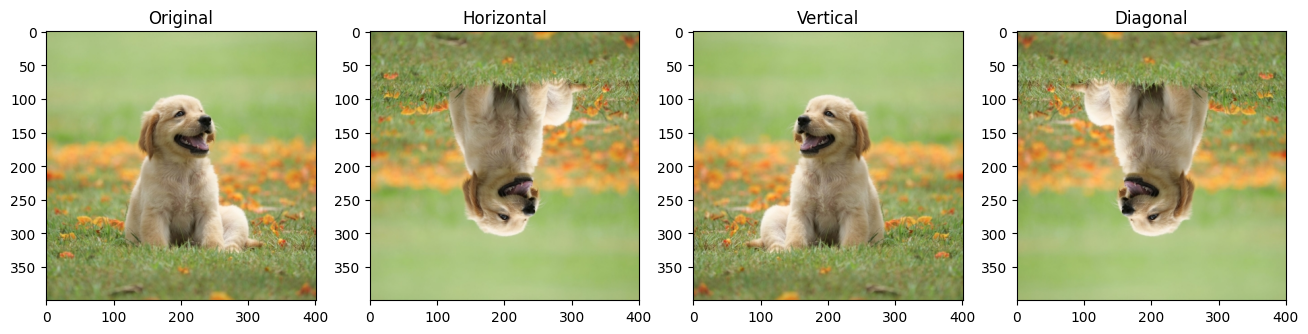

In [50]:
plt.figure(figsize=(16,9))
plt.subplot(141); plt.imshow(img_rgb); plt.title('Original')
plt.subplot(142); plt.imshow(img_hor); plt.title('Horizontal')
plt.subplot(143); plt.imshow(img_ver); plt.title('Vertical')
plt.subplot(144); plt.imshow(img_dia); plt.title('Diagonal')

In [55]:
## Stacking on array above other using numpy

x = np.array([[4,5,7],[1,8,9]])
y = np.array([[8,0,2],[4,2,1]])
x.shape, y.shape

((2, 3), (2, 3))

In [53]:
np.vstack([x,y])

array([[4, 5, 7],
       [1, 8, 9],
       [8, 0, 2],
       [4, 2, 1]])

In [54]:
np.hstack([x,y])

array([[4, 5, 7, 8, 0, 2],
       [1, 8, 9, 4, 2, 1]])

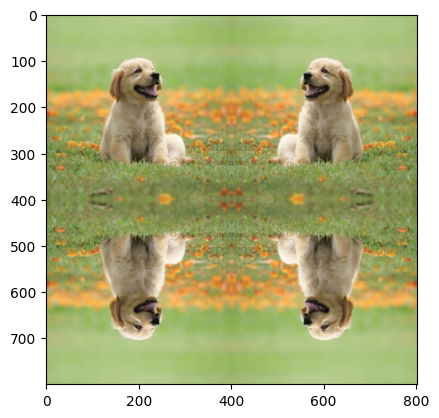

In [60]:
new_img1 = np.vstack([img_rgb, img_hor])
new_img2 = np.vstack([img_ver, img_dia])
new_img3 = np.hstack([new_img1, new_img2])
plt.imshow(new_img3)

#### Image Cropping

In [63]:
# Crop the image 15% from every side

height, width, _  = img_rgb.shape


In [64]:
start_row = int(height * 0.15)
start_col = int(width * 0.15)
end_row = int(height * 0.85)
end_col = int(width * 0.85)

In [65]:
img_crop = img_rgb[start_row:end_row, start_col:end_col]

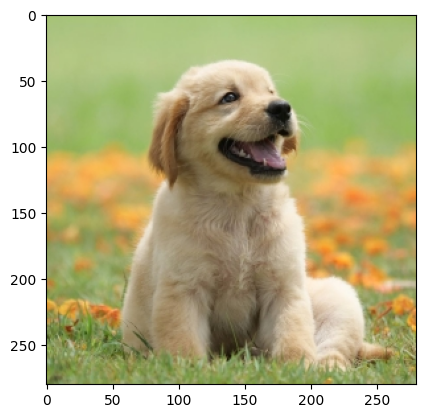

In [66]:
plt.imshow(img_crop)